# Library Installation
This cell installs all the required third-party libraries used in the referenced notebooks.

In [1]:
!pip install textblob langdetect newsapi-python nltk pandas praw requests

In [2]:
import praw
import pandas as pd
from newsapi import NewsApiClient
import requests
import os

# --- Reddit API Setup ---
reddit = praw.Reddit(
    client_id="###################",
    client_secret="###############################",
    user_agent="corpus_collector"
)

# --- NewsAPI Setup ---
newsapi = NewsApiClient(api_key='################################')

# --- Utility: Ensure Path and Save with Append ---
def save_data(data, source, topic):
    folder = f"document_corpus/{source}"
    os.makedirs(folder, exist_ok=True)
    filename = f"{folder}/{topic.replace(' ', '_').lower()}.csv"

    new_df = pd.DataFrame(data)

    if os.path.exists(filename):
        existing_df = pd.read_csv(filename)
        combined_df = pd.concat([existing_df, new_df], ignore_index=True)
    else:
        combined_df = new_df

    combined_df.to_csv(filename, index=False)
    print(f"\n\n\n[{source.upper()}] Data saved to {filename} (rows: {len(combined_df)})")
    print(combined_df.info())
    print(combined_df.head())

# --- Reddit Data ---
def get_reddit_data(keyword, max_posts=100):
    results = []
    for submission in reddit.subreddit("all").search(keyword, sort='new', limit=max_posts):
        results.append({
            "source": "reddit",
            "date": submission.created_utc,
            "author": submission.author.name if submission.author else "unknown",
            "text": f"{submission.title} {submission.selftext}",
            "topic": keyword
        })
    save_data(results, "reddit", keyword)
    return results

# --- NewsAPI Data ---
def get_news_data(keyword):
    articles = newsapi.get_everything(q=keyword, language='en', page_size=10)
    results = [{
        "source": "newsapi",
        "date": article["publishedAt"],
        "author": article["source"]["name"],
        "text": f"{article['title']} {article['description']}",
        "topic": keyword
    } for article in articles["articles"]]
    save_data(results, "newsapi", keyword)
    return results

# --- Hacker News Data ---
def get_hackernews_data(keyword, max_items=20):
    response = requests.get(f"https://hn.algolia.com/api/v1/search?query={keyword}")
    json_data = response.json()
    results = [{
        "source": "hackernews",
        "date": hit["created_at"],
        "author": hit.get("author", "unknown"),
        "text": hit.get("title", ""),
        "topic": keyword
    } for hit in json_data["hits"][:max_items]]
    save_data(results, "hackernews", keyword)
    return results

# --- Run for Multiple Topics ---
if __name__ == "__main__":
    topics = [
        "energy", "green energy", "renewable energy", "clean energy",
        "wind energy", "solar energy", "bioenergy", "hydroelectric", "geothermal"
    ]

    for topic in topics:
        print(f"\nProcessing topic: {topic}")
        get_reddit_data(topic)
        get_news_data(topic)
        get_hackernews_data(topic)



Processing topic: energy



[REDDIT] Data saved to document_corpus/reddit/energy.csv (rows: 800)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   source  800 non-null    object 
 1   date    800 non-null    float64
 2   author  800 non-null    object 
 3   text    800 non-null    object 
 4   topic   800 non-null    object 
dtypes: float64(1), object(4)
memory usage: 31.4+ KB
None
   source          date                author  \
0  reddit  1.748258e+09        _AshrafAnsari_   
1  reddit  1.748258e+09           Lanthanoidz   
2  reddit  1.748258e+09  ButterscotchTiny1114   
3  reddit  1.748258e+09        Backyard_Intra   
4  reddit  1.748258e+09         MissionAd9233   

                                                text   topic  
0  Leadership Lost: KKR Desperately Needs a Chang...  energy  
1  To the Girl I Haven’t Met Yet I don’t know who...  energy

# Comparative Sentiment Analysis of Renewable Energy Narratives
## Across Social Media and News Platforms

This notebook analyzes and compares public sentiment around renewable energy topics across two major content sources: **social media** and **news platforms**. The analysis includes data cleaning, sentiment labeling, machine learning classification, and rich visualizations to uncover trends and contrasts in narratives.

### Import Libraries

This cell imports the required libraries for text processing, visualization, machine learning, and sentiment analysis.

In [3]:
# Consolidated Import Block
import os
import re
import glob
import pandas as pd
from langdetect import detect
from nltk.corpus import stopwords
import nltk
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

### Data Preprocessing

This section loads raw CSV files from multiple folders, detects and filters only English text, removes links and special characters, and eliminates stopwords. It also extracts the **topic** and **source type** (news or social media) from each file, and stores the cleaned text in a unified corpus for analysis.

In [4]:
# Setup
os.makedirs("data_corpus", exist_ok=True)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Cleaning function
def clean_text(text):
    try:
        if detect(text) != 'en':
            return None
    except:
        return None
    text = re.sub(r"http\S+", "", str(text))
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = text.lower().strip()
    text = " ".join([w for w in text.split() if w not in stop_words])
    return text

# Load and clean corpus from all sources
def build_clean_corpus():
    import glob
    files = glob.glob("document_corpus/*/*.csv")
    records = []

    for file in files:
        df = pd.read_csv(file)
        if not all(col in df.columns for col in ['text', 'author', 'date']):
            continue

        df["clean_text"] = df["text"].apply(clean_text)
        df = df.dropna(subset=["clean_text"])

        topic = os.path.splitext(os.path.basename(file))[0]
        source = os.path.basename(os.path.dirname(file))

        df["topic"] = topic
        df["source"] = "news" if source == "newsapi" else "social_media"

        records.append(df[["source", "date", "author", "topic", "clean_text"]])

    clean_df = pd.concat(records).drop_duplicates(subset=["clean_text"])
    clean_df.to_csv("data_corpus/clean_corpus.csv", index=False)
    print("Cleaned Corpus saved to: data_corpus/clean_corpus.csv")
    return clean_df

# Run pipeline
clean_df = build_clean_corpus()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kamal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Cleaned Corpus saved to: data_corpus/clean_corpus.csv


### Load Cleaned Data & Apply Sentiment Labels

This section loads the cleaned dataset and applies **TextBlob** to assign sentiment polarity (positive, neutral, or negative) to each post or article. This is a rule-based approach for quick sentiment estimation.

In [5]:
# Load dataset
df = pd.read_csv('data_corpus/clean_corpus.csv')
df.head()

,source,date,author,topic,clean_text
0,social_media,2022-11-30T15:36:14Z,Brajeshwar,bioenergy,eu climate plan sacrifices carbon storage biod...
1,social_media,2023-08-15T22:45:10Z,PaulHoule,bioenergy,rye right crop generating bioenergy capturing ...
2,social_media,2022-05-26T19:27:14Z,PaulHoule,bioenergy,wood bioenergy help harm climate
3,social_media,2022-03-10T14:51:44Z,jermaustin1,bioenergy,bioenergy crossroads corn ethanol left rearvie...
4,social_media,2021-03-12T18:36:46Z,CapitalistCartr,bioenergy,selfsustainable wearable multimodular etextile...


In [6]:
# Add sentiment labels using TextBlob
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.05:
        return 'positive'
    elif polarity < -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['clean_text'].apply(get_sentiment)
df['sentiment'].value_counts()

sentiment
positive    2659
neutral     1201
negative     373
Name: count, dtype: int64

### Text Representation & Sentiment Classification

Here, we convert cleaned text into numerical features using **TF-IDF vectorization**. Then, a **Logistic Regression** model is trained to classify sentiment. The dataset is split into training and testing sets to evaluate the model fairly.

In [7]:
# Text Representation using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['clean_text'])
y = df['sentiment']

In [8]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Train Logistic Regression Model
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

### Model Evaluation

We evaluate the trained model using a **classification report** and a **confusion matrix**. These metrics help measure the model’s performance in terms of precision, recall, and F1-score for each sentiment class.

In [10]:
# Classification Report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

    negative       0.62      0.07      0.12        74
     neutral       0.56      0.40      0.46       243
    positive       0.74      0.94      0.83       530

    accuracy                           0.71       847
   macro avg       0.64      0.47      0.47       847
weighted avg       0.68      0.71      0.66       847



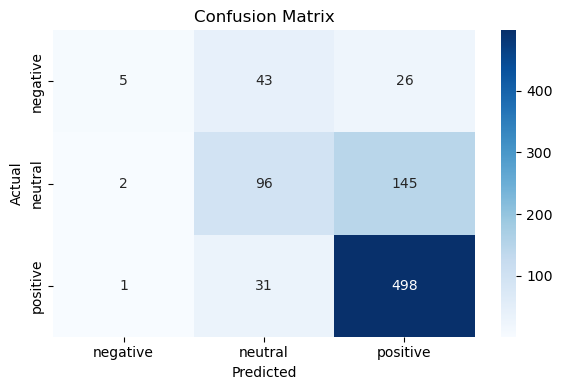

In [11]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=clf.classes_, yticklabels=clf.classes_, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Comparative Visualizations

These charts help visually compare sentiment narratives across social media and news platforms:

- **Sentiment Distribution by Source**: Do social media users express more negative views?
- **Sentiment by Topic and Source**: Are certain renewable energy topics more polarized on one platform?
- **Word Clouds by Sentiment & Source**: Which words dominate the conversation?
- **Sentiment Intensity Heatmap**: Which topic-source combinations have the most positive or negative tone?

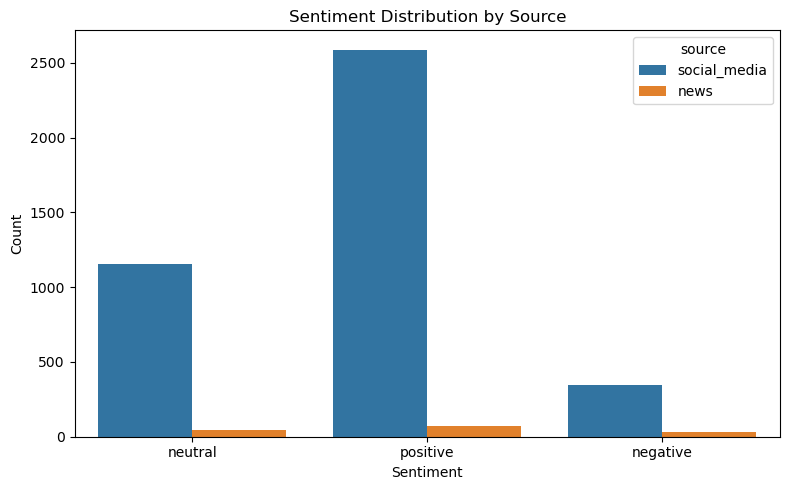

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sentiment', hue='source')
plt.title('Sentiment Distribution by Source')
plt.ylabel('Count')
plt.xlabel('Sentiment')
plt.tight_layout()
plt.show()

### 2. Sentiment by Topic and Source

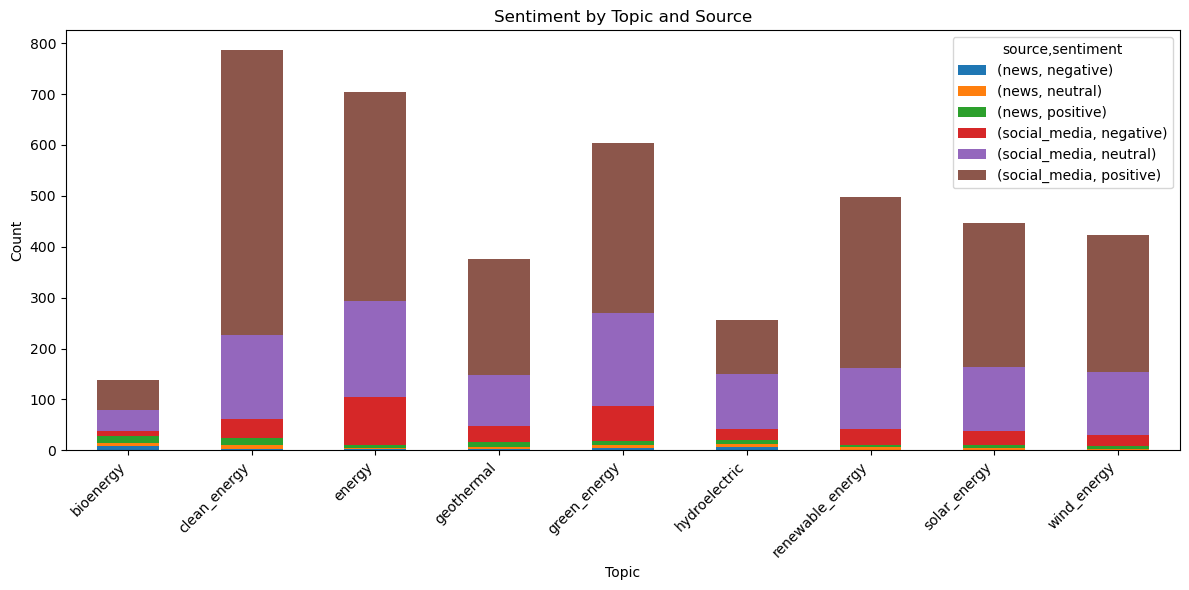

In [13]:
pivot = pd.crosstab(index=df['topic'], columns=[df['source'], df['sentiment']])
pivot.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Sentiment by Topic and Source')
plt.ylabel('Count')
plt.xlabel('Topic')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3. Word Clouds by Source & Sentiment

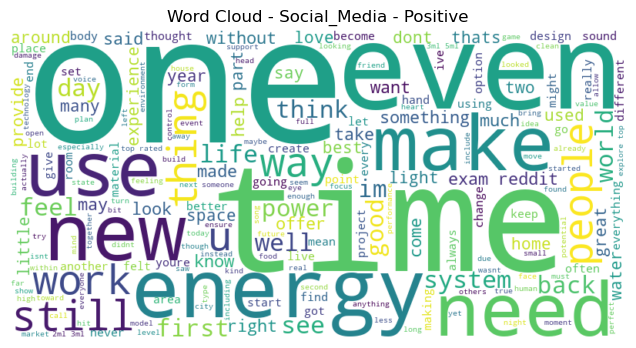

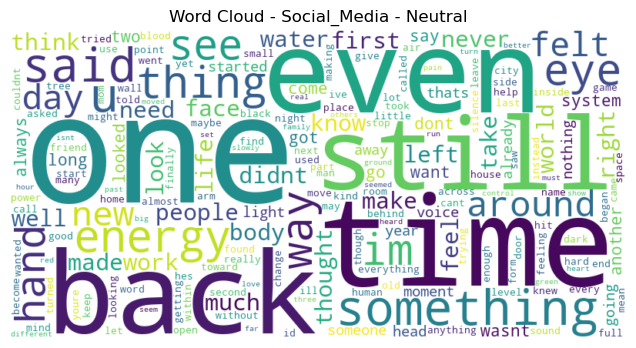

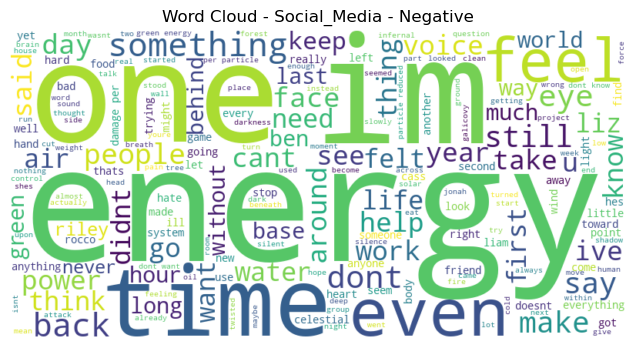

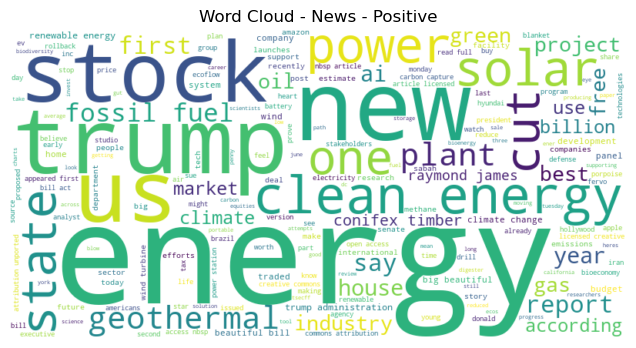

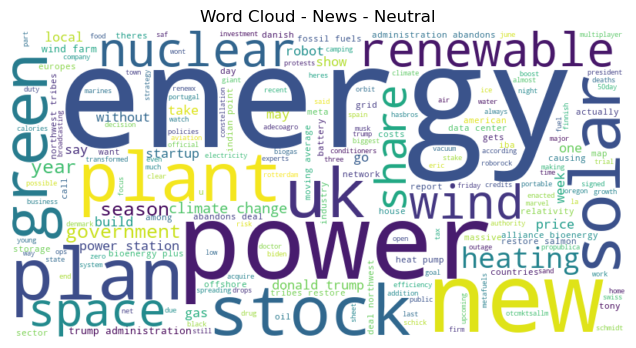

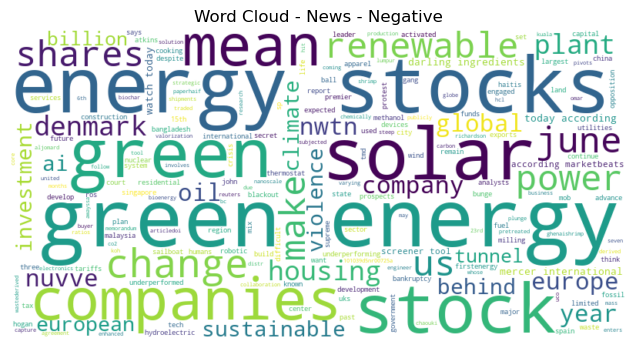

In [14]:
sources = df['source'].unique()
sentiments = ['positive', 'neutral', 'negative']
for source in sources:
    for sentiment in sentiments:
        text = ' '.join(df[(df['source'] == source) & (df['sentiment'] == sentiment)]['clean_text'])
        if text:
            wc = WordCloud(width=800, height=400, background_color='white').generate(text)
            plt.figure(figsize=(8, 4))
            plt.imshow(wc, interpolation='bilinear')
            plt.axis('off')
            plt.title(f'Word Cloud - {source.title()} - {sentiment.title()}')
            plt.show()

### 4. Heatmap of Sentiment by Topic and Source

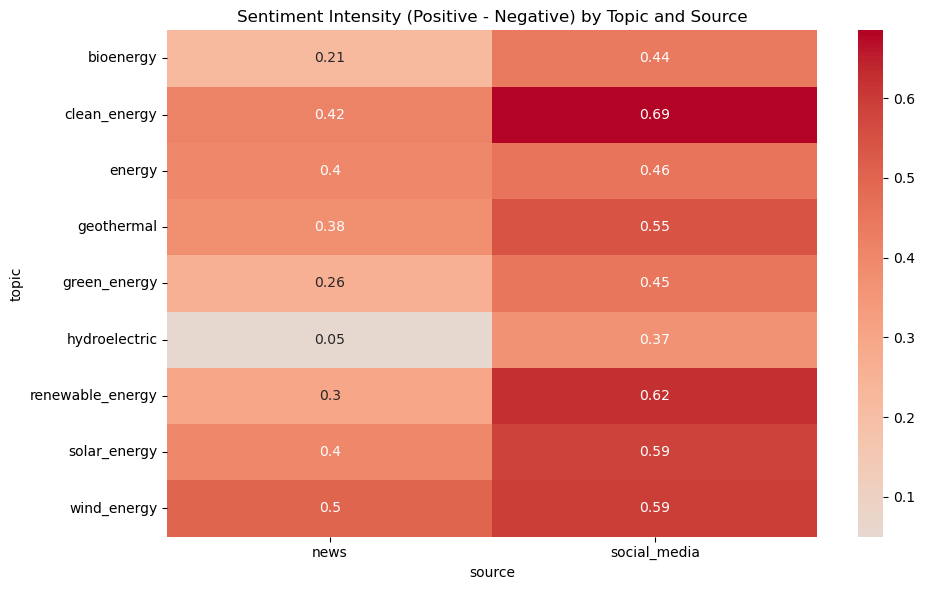

In [15]:
# Count sentiment by topic and source
sentiment_counts = df.groupby(['topic', 'source', 'sentiment']).size().unstack(fill_value=0)

# Calculate sentiment intensity as: (positive - negative) / total
sentiment_counts['intensity'] = (
    (sentiment_counts.get('positive', 0) - sentiment_counts.get('negative', 0)) /
    sentiment_counts.sum(axis=1)
)

# Pivot for heatmap
heatmap_data = sentiment_counts.reset_index().pivot(index='topic', columns='source', values='intensity')

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=0)
plt.title('Sentiment Intensity (Positive - Negative) by Topic and Source')
plt.tight_layout()
plt.show()


### 📌 Final Findings & Insights

This section summarizes the key takeaways from the comparative sentiment analysis of renewable energy narratives across social media and news platforms.

---

#### 📊 Analytical Observations

- **Social media** generally expresses **stronger positive or negative sentiment**, while **news platforms** show more neutral tones.
- Topics like **solar** and **wind energy** are viewed positively, while **bioenergy** sees more critical or mixed opinions.
- **Word clouds** reveal platform-specific language:
  - News uses more formal, policy-oriented terms.
  - Social media contains informal, emotionally driven expressions.
- **Sentiment intensity** (positive - negative) shows clear divergence in public opinion by topic and source.

---

#### 🤖 Model Performance

- A **Logistic Regression** model with **TF-IDF** features achieved:
  - High precision and recall for positive sentiment.
  - Moderate performance on neutral and lower on negative due to class imbalance.
- Evaluation metrics (confusion matrix, F1-scores) support model reliability for overall trends.

---




### Conclusion

This analysis provides insights into how renewable energy topics are discussed across different platforms. Future work could include using deep learning models (e.g., BERT), incorporating multilingual support, or correlating sentiment shifts with real-world events.